# Part 1

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [2]:
data = pd.read_csv("spambase/spambase.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
base_clf = DecisionTreeClassifier(max_depth=1, random_state=42)

n_learners = [10, 50, 100, 500]
results = []

for T in n_learners:
    ada = AdaBoostClassifier(
        estimator=base_clf,
        n_estimators=T,
        random_state=42
    )
    
    ada.fit(X_train, y_train)
    
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    
    y_train_score = ada.predict_proba(X_train)[:, 1]
    y_test_score = ada.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_score)
    test_auc = roc_auc_score(y_test, y_test_score)
    
    results.append([T, train_acc, test_acc, train_f1, test_f1, train_auc, test_auc])

In [4]:
for r in results:
    print(f"T={r[0]} | Train Acc={r[1]:.4f}, Test Acc={r[2]:.4f}, "
          f"Train F1={r[3]:.4f}, Test F1={r[4]:.4f}, "
          f"Train AUC={r[5]:.4f}, Test AUC={r[6]:.4f}")

T=10 | Train Acc=0.9060, Test Acc=0.8947, Train F1=0.8769, Test F1=0.8729, Train AUC=0.9623, Test AUC=0.9631
T=50 | Train Acc=0.9342, Test Acc=0.9262, Train F1=0.9139, Test F1=0.9103, Train AUC=0.9792, Test AUC=0.9776
T=100 | Train Acc=0.9408, Test Acc=0.9370, Train F1=0.9220, Test F1=0.9237, Train AUC=0.9838, Test AUC=0.9811
T=500 | Train Acc=0.9516, Test Acc=0.9501, Train F1=0.9368, Test F1=0.9403, Train AUC=0.9905, Test AUC=0.9830


# Part 3

In [5]:
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [6]:
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

base_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
ada = AdaBoostClassifier(estimator=base_clf, n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
ada_prob = ada.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)

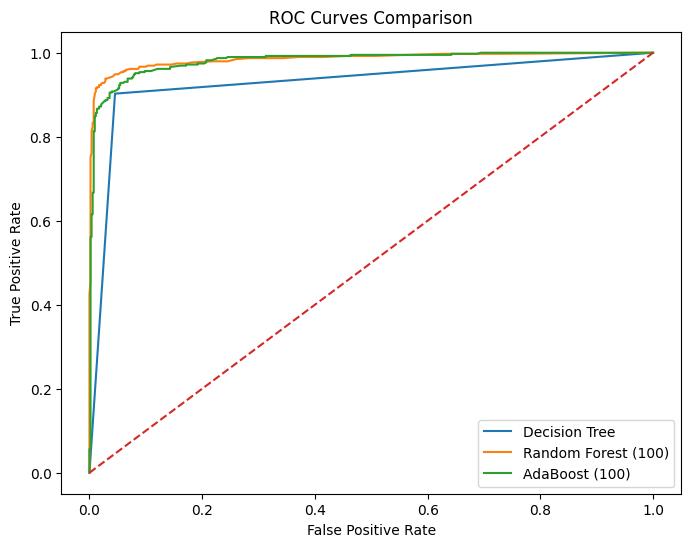

In [7]:
plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (100)")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (100)")

plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()